# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.


shape:  (30478, 13) 

df.types: 
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 



<Axes: >

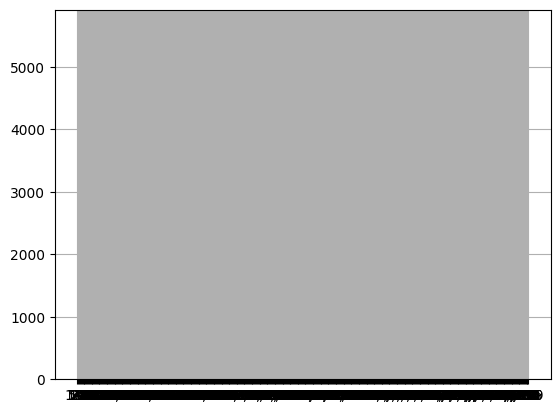

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/data/airbnb_hw.csv')

print(f'shape: ', df.shape,'\n')
print('df.types: ')
print(df.dtypes,'\n')
#df.head()

price = "Price"
#print(df[price].unique(), 'n')
#df[price].hist()

print('before coercion:\n', df[price].describe(), '\n')
df[price].hist(bins=50)



after coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: price_num_clean, dtype: float64 

total missings:
 0 



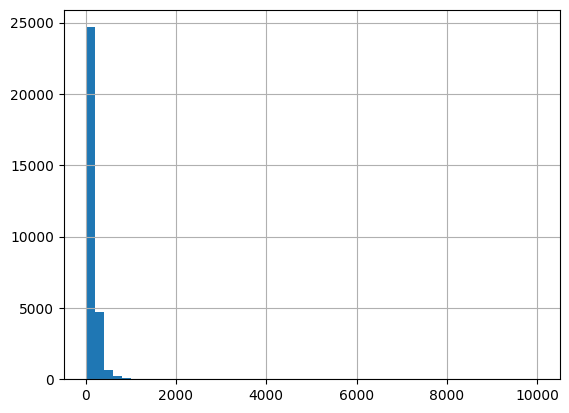

In [4]:
df['price_clean'] = df[price].str.replace(',', '')
df['price_num_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df['price_num_nan']=df['price_num_clean'].isnull()

print('after coercion:\n', df['price_num_clean'].describe(), '\n')
df['price_num_clean'].hist(bins=50)
print('total missings:\n', sum(df['price_num_nan']), '\n')

#Thought process:
# I first evaluated the price variable to understand if it was numeric or not by describing
# it and plotting a histogram, with which nothing showed up. I then converted the values to
# numeric and converted all leftovers to missing values (which only ended up being 181 values
# out of ~30000 total values) When I do this however, values with a comma (anything over 1000)
# turned into a missing value, as the max is 999. I then spoke with the professor, who confirmed that
# I should remove all of the commas, and then afterwards convert the values to numeric. This way,
# there are no missing values and the result is more accurate

In [6]:
#Dealing with police use of force
df1 = pd.read_csv('/content/data/mn_police_use_of_force.csv')

df1.head()




,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [9]:
var = 'subject_injury'
print(len(df1[var]),'\n')
print(df1[var].unique(),'\n')
df1[var] = df1[var].fillna('Not Stated')
print(df1[var].value_counts(),'\n')

pd.crosstab(df1['subject_injury'], df1['force_type'])

# Most of the not stated values (NaN for subject injury) occur when there is bodily force or chemical irritant.
# The only two cases of firearms included in this dataset actually show that there is no subject injury,
# which is interesting. Also, there is nothing stated during "less lethal" force type and
# "maximal restraint technique" which is interesting. In total, NaN values in subject_injury make
# up 76% of the total recorded values, which is significant.

12925 

['Not Stated' 'No' 'Yes'] 

subject_injury
Not Stated    9848
Yes           1631
No            1446
Name: count, dtype: int64 



force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Not Stated,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [57]:
#Question 2:

df_shark = pd.read_excel('/content/data/GSAF5.xls')
df_shark_clean = df_shark.replace(r'^\s*$', np.nan, regex=True)
df_shark_clean = df_shark_clean.dropna(axis=1, how = "all")

df_test = df_shark_clean.replace(r'^\s*$', np.nan, regex=True)
print(df_test.isna().all())

#print(df_shark["pdf"].unique()[:20])
print(df_shark["pdf"].apply(type).value_counts())

df_shark_clean.head()

Date              False
Year              False
Type              False
Country           False
State             False
Location          False
Activity          False
Name              False
Sex               False
Age               False
Injury            False
Fatal Y/N         False
Time              False
Species           False
Source            False
pdf               False
href formula      False
href              False
Case Number       False
Case Number.1     False
original order    False
Unnamed: 21       False
Unnamed: 22       False
dtype: bool
pdf
<class 'str'>      6798
<class 'float'>     319
Name: count, dtype: int64


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


after coercion of Years:
 count         3934.0
mean     1989.577275
std        35.901609
min           1000.0
25%           1969.0
50%           2001.0
75%           2013.0
max           2026.0
Name: Year_clean, dtype: Float64 

after coercion of Age:
 count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64 

3948 

['M' 'F' nan] 

Sex
M             3330
F              584
Not Stated      34
Name: count, dtype: int64 



<Axes: >

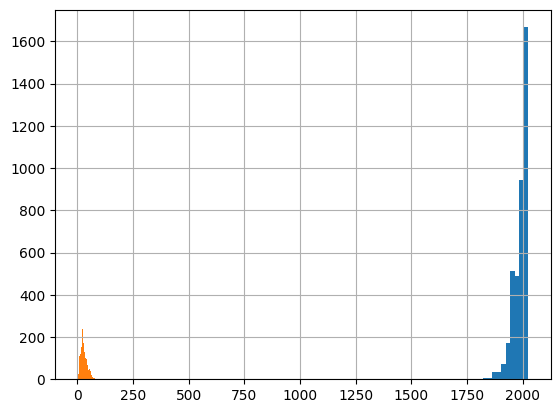

In [59]:
df_shark_clean['Year_clean'] = df_shark_clean['Year'].astype(str).str.extract(r'(\d{4})', expand=False)
df_shark_clean['Year_clean'] = pd.to_numeric(df_shark_clean['Year_clean'], errors='coerce')
df_shark_clean['Age_clean'] = pd.to_numeric(df_shark_clean['Age'], errors='coerce')


df_shark_clean['Year_clean'] = df_shark_clean['Year_clean'].astype('Int64')
df_shark_clean['Year_clean_null']=df_shark_clean['Year_clean'].isnull()

df_shark_filtered = df_shark_clean[df_shark_clean['Year_clean'] >= 1940].copy()
df_shark_filtered = df_shark_clean[df_shark_clean['Age_clean'].notna()].copy()

print('after coercion of Years:\n', df_shark_filtered['Year_clean'].describe(), '\n')
print('after coercion of Age:\n', df_shark_filtered['Age_clean'].describe(), '\n')

var = 'Sex'
df_shark_filtered[var] = df_shark_filtered[var].astype(str).str.strip().str.upper()
df_shark_filtered[var] = df_shark_filtered[var].replace('NAN', np.nan)
df_shark_filtered[var] = df_shark_filtered[var].replace('LLI', np.nan)
print(len(df_shark_filtered[var]),'\n')
print(df_shark_filtered[var].unique(),'\n')
df_shark_filtered[var] = df_shark_filtered[var].fillna('Not Stated')
print(df_shark_filtered[var].value_counts(),'\n')

df_sharl_clean['t']


df_shark_filtered['Year_clean'].hist(bins=50)
df_shark_filtered['Age_clean'].hist(bins=50)
#df_shark_clean.head(10)




## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]